## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load feature dataset
df = pd.read_csv('unified_features.csv')

print(f'Total records: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Total records: 223
Columns: ['location_id', 'lat', 'lon', 'traffic_volume', 'charger_count_nearby', 'renewable_score', 'road_density', 'ev_penetration_proxy']


,location_id,lat,lon,traffic_volume,charger_count_nearby,renewable_score,road_density,ev_penetration_proxy
0,1124,53.296715,-6.204066,1895.94,3,0.4102,20,0.049
1,6000,53.279287,-6.210832,987.26,3,0.4102,67,0.049
2,6001,53.293577,-6.201737,1917.98,5,0.4102,9,0.049
3,6002,53.293486,-6.201812,1975.50,5,0.4102,10,0.049
4,6003,53.282363,-6.193424,1467.48,0,0.4102,2,0.049


## 2. Exploratory Data Analysis

In [2]:
# Basic statistics
print('=== Basic Statistics ===')
print(df.describe())

# Check for missing values
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Basic Statistics ===
       location_id         lat         lon  traffic_volume  \
count   223.000000  223.000000  223.000000      223.000000   
mean   6156.964126   53.277807   -6.187689      773.555740   
std     363.165262    0.020204    0.042948      551.232089   
min    1124.000000   53.209599   -6.275690        0.000000   
25%    6058.500000   53.264640   -6.222761      335.780000   
50%    6160.000000   53.282388   -6.185137      686.680000   
75%    6294.000000   53.292799   -6.148450     1046.020000   
max    6406.000000   53.313452   -6.111462     2790.940000   

       charger_count_nearby  renewable_score  road_density  \
count            223.000000     2.230000e+02    223.000000   
mean               0.937220     4.102000e-01     29.618834   
std                1.450569     1.947261e-15     17.160425   
min                0.000000     4.102000e-01      2.000000   
25%                0.000000     4.102000e-01     16.000000   
50%                0.000000     4.102000e-01

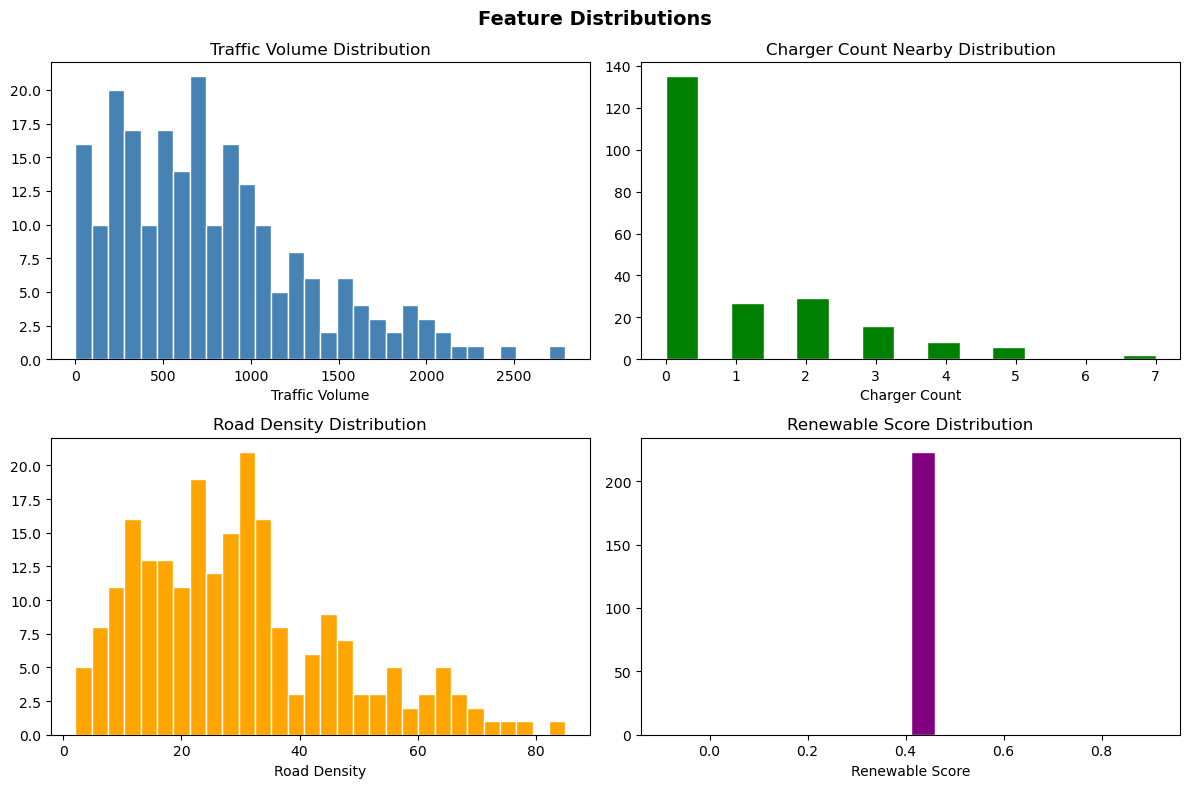

In [3]:
# Feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df['traffic_volume'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Traffic Volume Distribution')
axes[0, 0].set_xlabel('Traffic Volume')

axes[0, 1].hist(df['charger_count_nearby'], bins=15, color='green', edgecolor='white')
axes[0, 1].set_title('Charger Count Nearby Distribution')
axes[0, 1].set_xlabel('Charger Count')

axes[1, 0].hist(df['road_density'], bins=30, color='orange', edgecolor='white')
axes[1, 0].set_title('Road Density Distribution')
axes[1, 0].set_xlabel('Road Density')

axes[1, 1].hist(df['renewable_score'], bins=20, color='purple', edgecolor='white')
axes[1, 1].set_title('Renewable Score Distribution')
axes[1, 1].set_xlabel('Renewable Score')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Gap Score Calculation
Gap Score represents the supply-demand gap at each location:
- High traffic volume = high EV charging demand
- Low charger count = low supply
- High gap score = priority location for new charger

Gap Score Statistics:
count     223.000000
mean      539.976922
std       455.200124
min         0.000000
25%       206.466667
50%       385.560000
75%       757.775000
max      2284.550000
Name: gap_score, dtype: float64

Normalised Gap Score Statistics:
count    223.000000
mean       0.236360
std        0.199252
min        0.000000
25%        0.090375
50%        0.168768
75%        0.331696
max        1.000000
Name: gap_score_normalised, dtype: float64


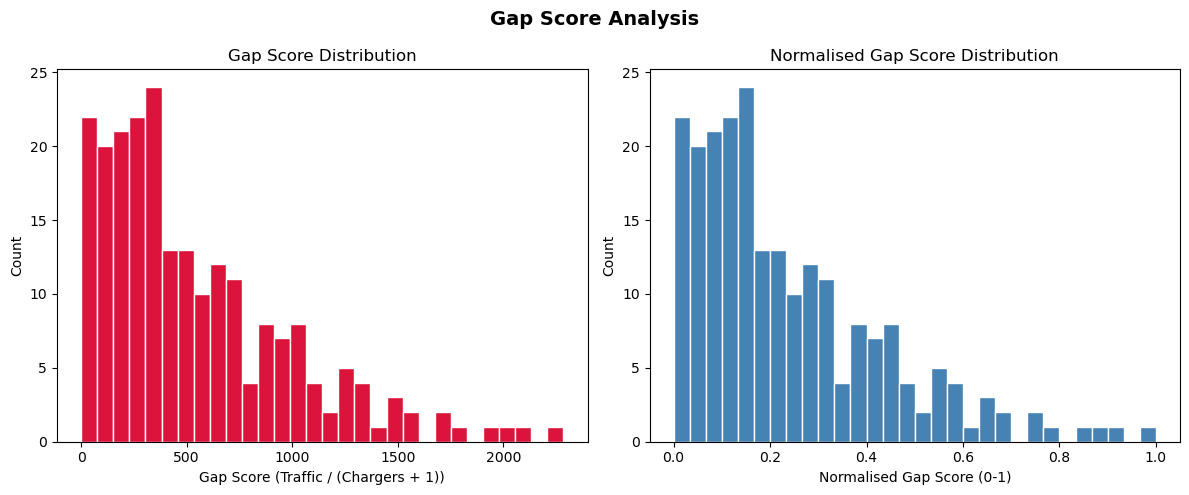

In [4]:
# Calculate gap score: demand / (supply + 1)
df['gap_score'] = df['traffic_volume'] / (df['charger_count_nearby'] + 1)

# Normalised gap score (0-1 scale, easier to interpret)
df['gap_score_normalised'] = (df['gap_score'] - df['gap_score'].min()) / (df['gap_score'].max() - df['gap_score'].min())

print('Gap Score Statistics:')
print(df['gap_score'].describe())
print('\nNormalised Gap Score Statistics:')
print(df['gap_score_normalised'].describe())

# Visualise both distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['gap_score'], bins=30, color='crimson', edgecolor='white')
axes[0].set_title('Gap Score Distribution')
axes[0].set_xlabel('Gap Score (Traffic / (Chargers + 1))')
axes[0].set_ylabel('Count')

axes[1].hist(df['gap_score_normalised'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Normalised Gap Score Distribution')
axes[1].set_xlabel('Normalised Gap Score (0-1)')
axes[1].set_ylabel('Count')

plt.suptitle('Gap Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gap_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Filter top 20% highest gap score locations
threshold = df['gap_score'].quantile(0.80)
df_priority = df[df['gap_score'] >= threshold].copy()

print(f'Total locations: {len(df)}')
print(f'Priority locations (top 20% gap score): {len(df_priority)}')
print(f'Gap score threshold: {threshold:.2f}')

Total locations: 223
Priority locations (top 20% gap score): 45
Gap score threshold: 898.58


## 4. Feature Scaling

In [6]:
# Select features for clustering
feature_cols = [
    'traffic_volume',
    'charger_count_nearby',
    'road_density',
    'gap_score',
    'renewable_score'  
]
# Standardise features
scaler = StandardScaler()
scaled = scaler.fit_transform(df_priority[feature_cols])

print('Features scaled successfully.')
print(f'Shape: {scaled.shape}')

Features scaled successfully.
Shape: (45, 5)


## 5. Elbow Method — Finding Optimal K

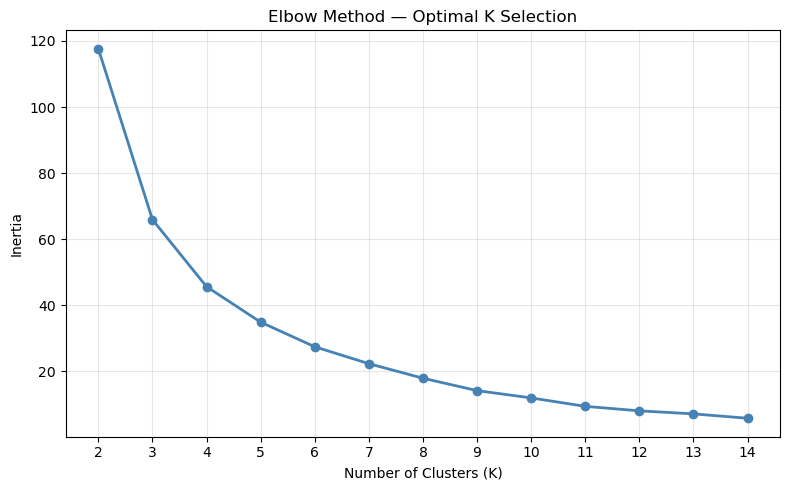

In [7]:
inertia = []
k_range = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertia.append(km.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal K Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. K-Means Clustering

In [8]:
# Run K-Means with K=10 (minimum requirement: ≥10 recommended locations)
K = 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(scaled)

df_priority['cluster'] = kmeans.labels_

print(f'K-Means completed with K={K}')
print('\nCluster sizes:')
print(df_priority['cluster'].value_counts().sort_index())

K-Means completed with K=10

Cluster sizes:
cluster
0     8
1     2
2     4
3    13
4     2
5     3
6     1
7     5
8     3
9     4
Name: count, dtype: int64


## 7. Silhouette Score — Evaluating Cluster Quality

In [9]:
score = silhouette_score(scaled, kmeans.labels_)
print(f'Silhouette Score: {score:.4f}')
print('(Score range: -1 to 1. Closer to 1 = better clustering quality)')

Silhouette Score: 0.4235
(Score range: -1 to 1. Closer to 1 = better clustering quality)


## 8. Recommended Locations — Cluster Centers

In [13]:
# Get cluster center coordinates (use mean lat/lon of each cluster)
cluster_centers = df_priority.groupby('cluster').agg(
    lat=('lat', 'mean'),
    lon=('lon', 'mean'),
    avg_traffic=('traffic_volume', 'mean'),
    avg_gap_score=('gap_score', 'mean'),
    avg_chargers=('charger_count_nearby', 'mean'),
    site_count=('location_id', 'count')
).reset_index()

# Rank by average gap score (highest = most urgent)
cluster_centers = cluster_centers.sort_values('avg_gap_score', ascending=False).reset_index(drop=True)
cluster_centers['rank'] = cluster_centers.index + 1

print('=== Top 10 Recommended New EV Charger Locations ===')
print(cluster_centers[['rank', 'lat', 'lon', 'avg_traffic', 'avg_gap_score', 'avg_chargers']].to_string(index=False))

# Add renewable score to cluster centers
cluster_centers['renewable_score'] = df_priority.groupby('cluster')['renewable_score'].mean().values

# Rename columns to match API format
output = cluster_centers.rename(columns={
    'cluster': 'cluster_id',
    'avg_traffic': 'traffic_volume',
    'avg_gap_score': 'gap_score',
    'avg_chargers': 'charger_count_nearby'
})[['rank', 'lat', 'lon', 'cluster_id', 'gap_score', 
    'traffic_volume', 'charger_count_nearby', 'renewable_score']]

# Save to CSV for backend API
output.to_csv('recommendations.csv', index=False)
print('\n=== Output saved to recommendations.csv ===')
print(output.to_string(index=False))

=== Top 10 Recommended New EV Charger Locations ===
 rank       lat       lon  avg_traffic  avg_gap_score  avg_chargers
    1 53.276568 -6.150112  2120.083333    2120.083333           0.0
    2 53.284673 -6.225359  1871.505000    1871.505000           0.0
    3 53.270964 -6.166149  1637.762500    1637.762500           0.0
    4 53.246493 -6.138492  2790.940000    1395.470000           1.0
    5 53.272330 -6.165894  1353.103750    1353.103750           0.0
    6 53.272437 -6.153836  1328.545000    1328.545000           0.0
    7 53.278150 -6.215849  1047.706667    1047.706667           0.0
    8 53.284652 -6.206248  1028.666154    1028.666154           0.0
    9 53.303163 -6.208056  1963.175000     981.587500           1.0
   10 53.284419 -6.233367   980.380000     980.380000           0.0

=== Output saved to recommendations.csv ===
 rank       lat       lon  cluster_id   gap_score  traffic_volume  charger_count_nearby  renewable_score
    1 53.276568 -6.150112           5 2120.083333 

## 9. Map Visualisation

In [11]:
# Colour palette for clusters
COLORS = [
    'red', 'blue', 'green', 'purple', 'orange',
    'darkred', 'cadetblue', 'darkgreen', 'darkpurple', 'darkblue'
]

# Create map
m = folium.Map(location=[53.33, -6.25], zoom_start=12)

# Plot all priority sites
for _, row in df_priority.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color=COLORS[int(row['cluster'])],
        fill=True,
        fill_opacity=0.5,
        popup=f"Site: {row['location_id']}<br>Traffic: {row['traffic_volume']:.0f}<br>Gap Score: {row['gap_score']:.1f}"
    ).add_to(m)

# Plot recommended locations (cluster centers)
for _, row in cluster_centers.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Rank #{int(row['rank'])}<br>Avg Traffic: {row['avg_traffic']:.0f}<br>Avg Gap Score: {row['avg_gap_score']:.1f}",
        icon=folium.Icon(color='red', icon='bolt', prefix='fa')
    ).add_to(m)

m.save('kmeans_recommendations.html')
print('Map saved as kmeans_recommendations.html')
m

Map saved as kmeans_recommendations.html


## 10. Summary

In [12]:
print('=== K-Means Clustering Summary ===')
print(f'Total SCATS sites analysed:     {len(df)}')
print(f'Priority sites (top 20% gap):   {len(df_priority)}')
print(f'Number of clusters (K):         {K}')
print(f'Silhouette Score:               {score:.4f}')
print(f'Recommended new locations:      {len(cluster_centers)}')
print()
print('Top 3 priority locations:')
for _, row in cluster_centers.head(3).iterrows():
    print(f"  Rank #{int(row['rank'])}: ({row['lat']:.4f}, {row['lon']:.4f}) — Gap Score: {row['avg_gap_score']:.1f}")


=== K-Means Clustering Summary ===
Total SCATS sites analysed:     223
Priority sites (top 20% gap):   45
Number of clusters (K):         10
Silhouette Score:               0.4235
Recommended new locations:      10

Top 3 priority locations:
  Rank #1: (53.2766, -6.1501) — Gap Score: 2120.1
  Rank #2: (53.2847, -6.2254) — Gap Score: 1871.5
  Rank #3: (53.2710, -6.1661) — Gap Score: 1637.8
